# Cloud phase by FRACTION of cloud water path — surface classes

The same figures as `plot_lwp_histogram_by_surface_class.ipynb`, but with the
three cloud-phase categories defined by each species' **share** of the cloud
water path rather than by absolute thresholds in g m-2.

```
CWP = LWP + IWP                    (cloud water path)

liquid only   LWP/CWP >= liquid_fraction_min   (default 0.90)
ice only      IWP/CWP >= ice_fraction_min      (default 0.90)
mixed phase   everything else holding cloud water
```

Both notebooks drive the **same module**, `plot_lwp_histogram_by_surface_class.py`,
through `phase_mode="fraction"` — there is no second copy of the analysis code
to drift out of step. Everything downstream of the phase masks (surface
classification, the per-cell hour normalisation, the seasons, the figures) is
identical.

### Why this scheme differs in kind, not just in numbers

Because `LWP/CWP` and `IWP/CWP` sum to exactly 1, the three categories are
**mutually exclusive and exhaustive by construction** over every scene holding
cloud water. There is no gap to account for and no overlap to guard — given
one condition, below. The absolute scheme cannot promise that: its categories
leave a real population in neither.

It asks *what is this cloud made of* rather than *how much of each does it
hold*, so a thin cloud and a thick one are classified on the same footing.
That is the point, and also the risk: a scene with 0.05 g m-2 of liquid and
nothing else is 100% liquid by share. The minimum paths below are what keep
the ratio off numerical dust.

| Cell | What it does |
|---|---|
| Load | `prepare(phase_mode="fraction", ...)` -> an `Analysis` |
| Report | hours per class and phase, and the partition check |
| Figure 1 | linear LWP bins |
| Figure 2 | log-spaced LWP bins |
| Figure 3 | monthly phase occupancy, one panel per month |

## Setup

In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures/fraction_limits")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the data

The slow cell. `phase_mode="fraction"` selects the fractional scheme; the four
thresholds below are the only ones it reads. The absolute-mode options
(`liquid_lwp_min`, `mixed_iwp_min`, `ice_iwp_min`, ...) are ignored here.

### The two fractional cuts

**One constraint:** `liquid_fraction_min + ice_fraction_min > 1`. Writing
`f = LWP/CWP`, liquid-only is `f >= a` and ice-only is `f <= 1 - b`; those
intervals are disjoint exactly when `a > 1 - b`. The inequality is **strict** —
at `a + b == 1` (say 0.5 and 0.5) they still touch at the single point
`f = 0.5`. `prepare()` raises a `ValueError` explaining the violation rather
than double-counting. The defaults sum to 1.8.

### The two minimum paths

A species below its floor is treated as **absent** — contributing neither to
CWP nor to its own share — rather than the scene being thrown away. So a cloud
with LWP 50 and IWP 0.05 g m-2 is liquid-only outright, instead of liquid-only
by a ratio of 0.999 that happens to clear the cut. A scene with *both* species
below their floor holds no cloud water and is the only unclassified case; it
shows up as the report's `neither` column, which should be near zero.

In [ ]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2022, 2026)),   # season START years
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",            # <- the fractional scheme

    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.90,            # IWP/CWP at or above this = ice only
                                      # (must sum to more than 1.0)

    min_lwp=0.1,                      # g m-2, liquid below this counts as absent
    min_iwp=0.1,                      # g m-2, ice below this counts as absent

    min_cloud_fraction=0.99,                         # overcast only
    lsm_tol = 0.01,                                 # land-sea mask tolerance for 
                                                    # classifying a grid cell as land or sea
    open_ocean_max_siconc = 0.05,                       # maximum sea ice concentration for a grid cell to be
                                                    # considered open ocean
    sea_ice_min_siconc = 0.95,                          # minimum sea ice concentration for a grid cell to be
                                                    # considered sea ice,     
    storage="local",
    dpi=350,
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 107,856 time steps
  Season     : 08-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.9 | mixed: the rest | CWP = LWP + IWP above 0.1/0.1 g m-2
               ice only: IWP/CWP >= 0.9
  LWP bins   : linear 0-600 in 24 | log 0.1-1000 in 12

  Seasons found (18), coverage of the 244-day window:
    1999/2000:  37.3%   (below --min-season-coverage)
    2000/2001:  99.6%
    2001/2002:  62.7%
    2011/2012: 100.0%
    2012/2013:  99.6%
    2013/2014:  99.6%
    2014/2015:  99.6%
    2015/2016: 100.0%
    2016/2017:  99.6%
    2017/2018:  95.1%
    2018/2019:  99.6%
    2019/2020: 100.0%
    2020/2021:  99.6%
    2021/2022:  99.6%
    20

## Numeric report

Hours per season per grid cell in each surface class, split into `liquid`,
`mixed`, `ice` and `neither`. Under this scheme `neither` means one thing only
— no cloud water above the minimum paths — and should be small; the three
phases are exhaustive over everything else. The residual on that partition is
printed as a check.

In [27]:
lwph.print_report(A)


  Hours per season per grid cell (5,856 h in the window), mean over 15 season(s):
    class                  mean area %   cloudy   liquid    mixed      ice  neither  liq+mix %  med LWP liq  med LWP mix
    --------------------------------------------------------------------------------------------------------------------
    Land                          0.69     2648      484     1228      926       10       64.6          166         31.6
    Coastal (mixed)              11.66     2938      564     1430      937        7       67.9          131         29.2
    Open ocean                   21.52     3785     1717     1874      194        0       94.9          112         70.2
    Marginal ice zone            19.90     4204      948     2353      900        3       78.5         90.3         29.4
    Sea ice                      46.23     3482      188     1407     1835       52       45.8         43.5         11.4
    Utqiagvik (ARM site)        1 cell     3197      679     1598     

## Figures

Each cell reads `A` and returns a `matplotlib` figure. Pass `out_dir=` to
save. Nothing below re-reads the archive.

Note the LWP axis of figures 1 and 2 is still an **absolute** g m-2 axis — the
fractional scheme changes how each hour is *classified*, not what the
histogram is binned by.

### 1. Linear LWP bins

  -> figures/fraction_limits/barrow_lwp_hist_surfaceclass_linear_mean2011-2025.png


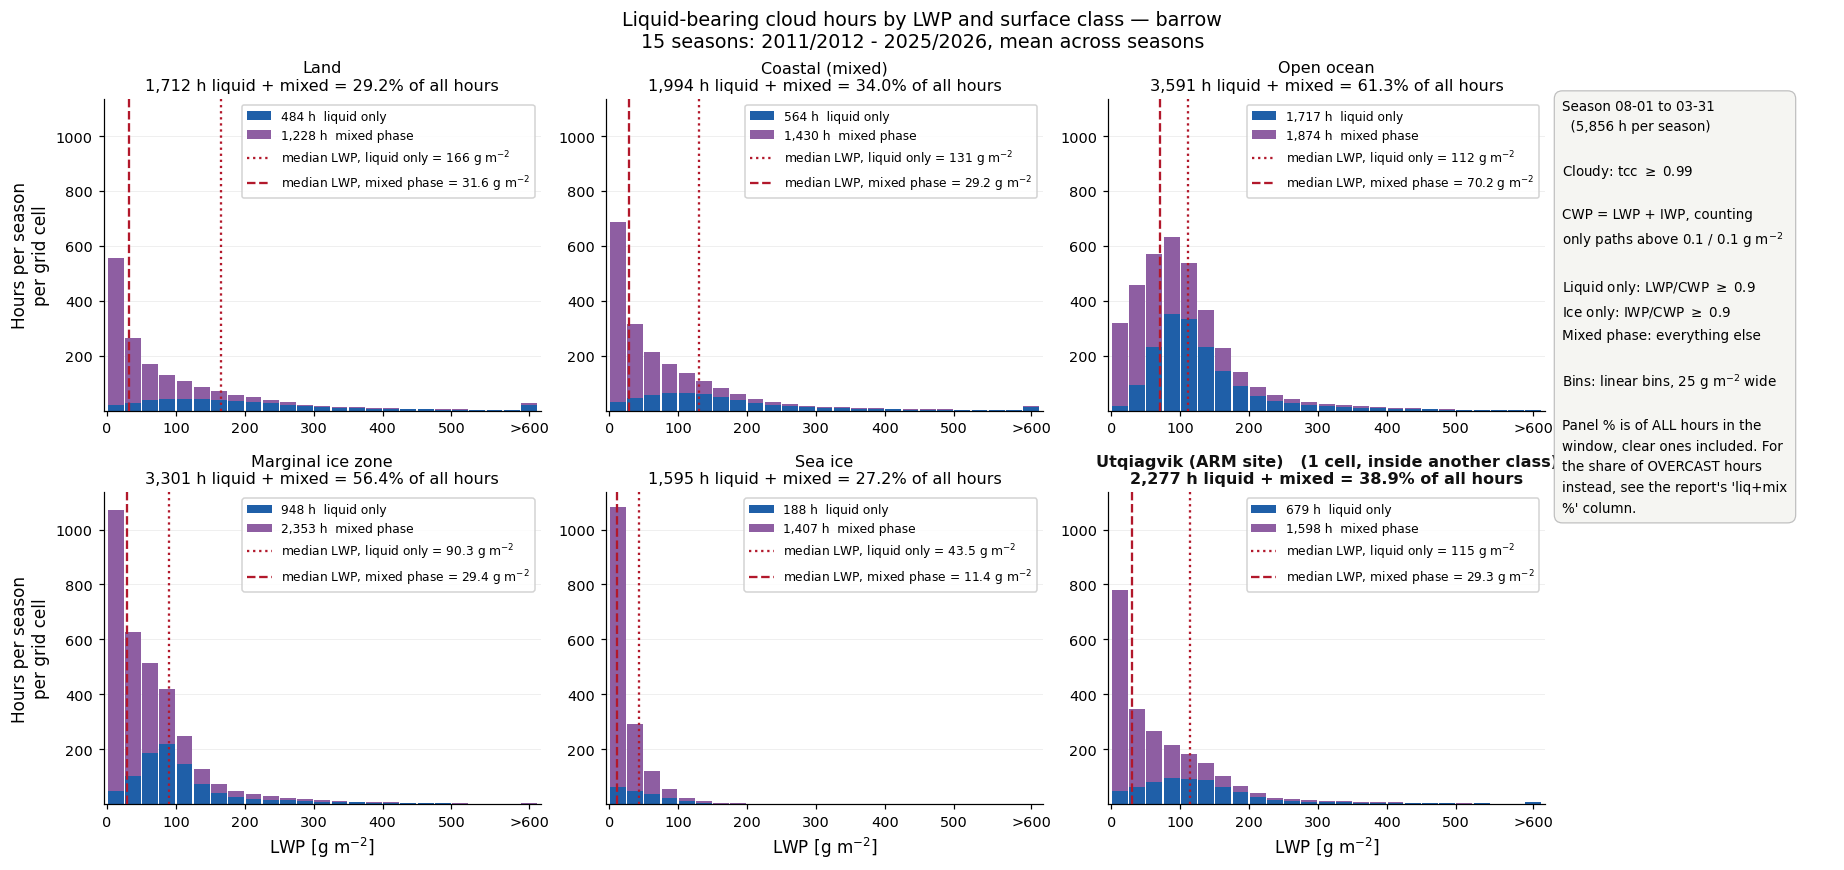

In [28]:
lwph.fig_linear(A, out_dir=SAVE_DIR);

### 2. Log-spaced LWP bins

The log axis starts at `min_lwp` by default, since no drawn hour can carry
less liquid than that.

  -> figures/fraction_limits/barrow_lwp_hist_surfaceclass_log_mean2011-2025.png


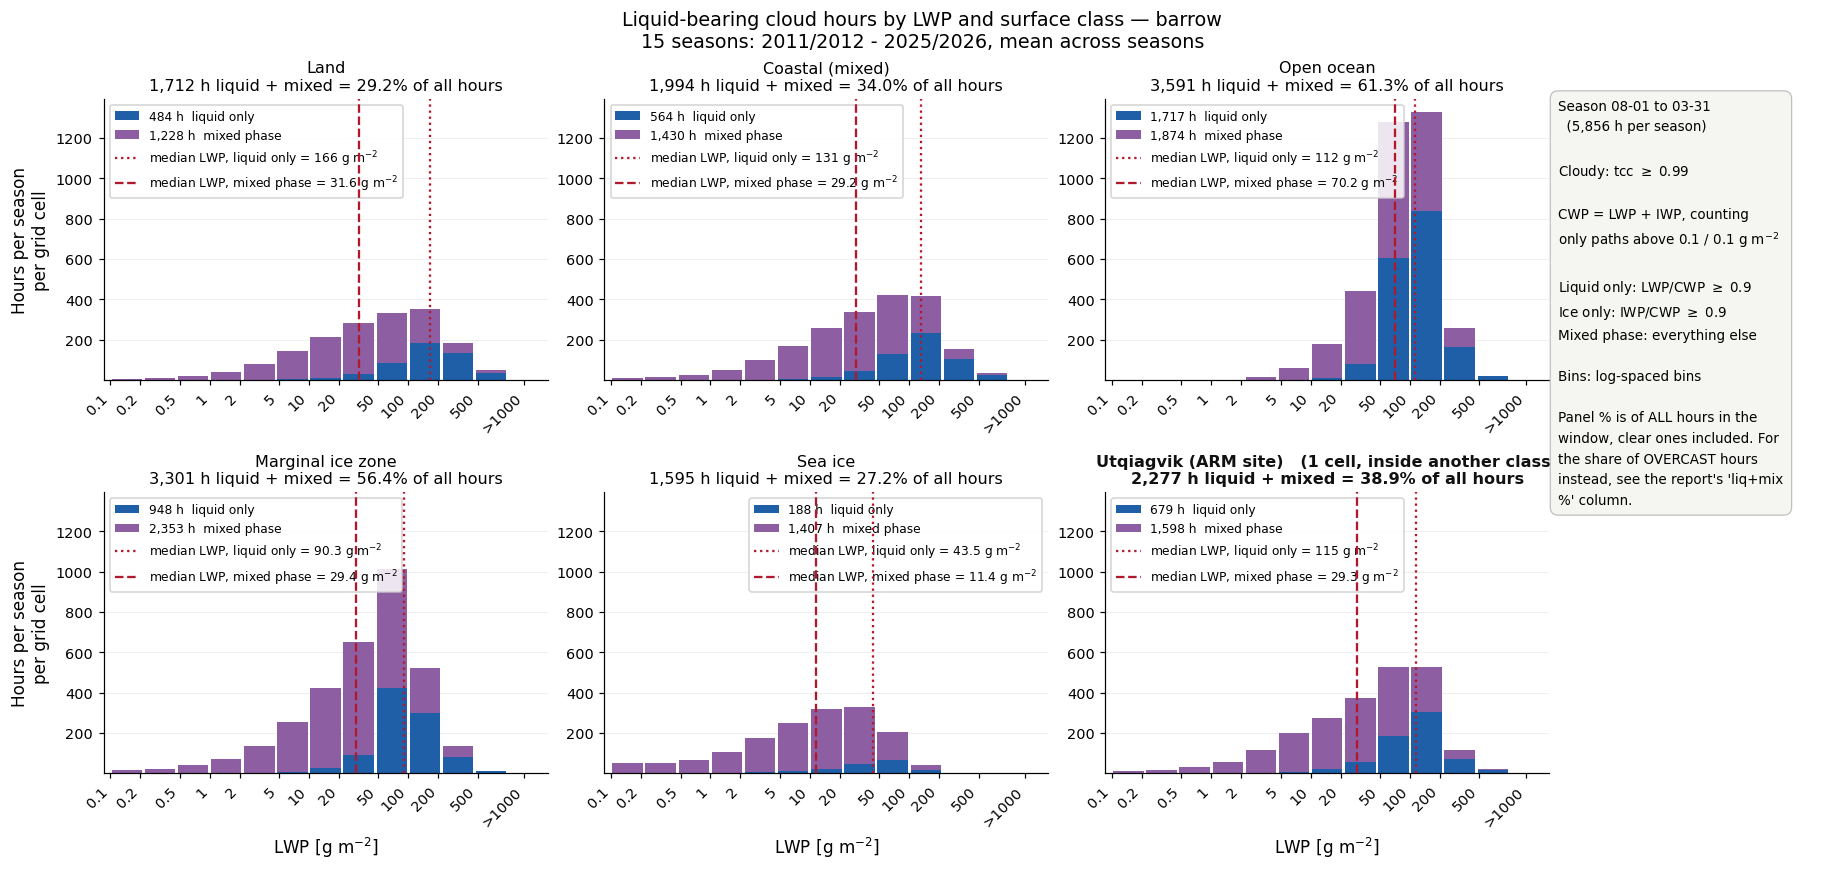

In [29]:
lwph.fig_log(A, out_dir=SAVE_DIR);

### 3. Monthly cloud-phase occupancy

One panel per month, three bars each. Under the fractional scheme these three
bars come much closer to summing to the month's overcast share than they do
under absolute thresholds, because only the no-cloud-water scenes are left
out.

Panel grid follows the season: **2 x 3** for Oct-Mar, **2 x 4** for Aug-Mar.

  -> figures/fraction_limits/barrow_monthly_phase_fraction_all_mean2011-2025.png


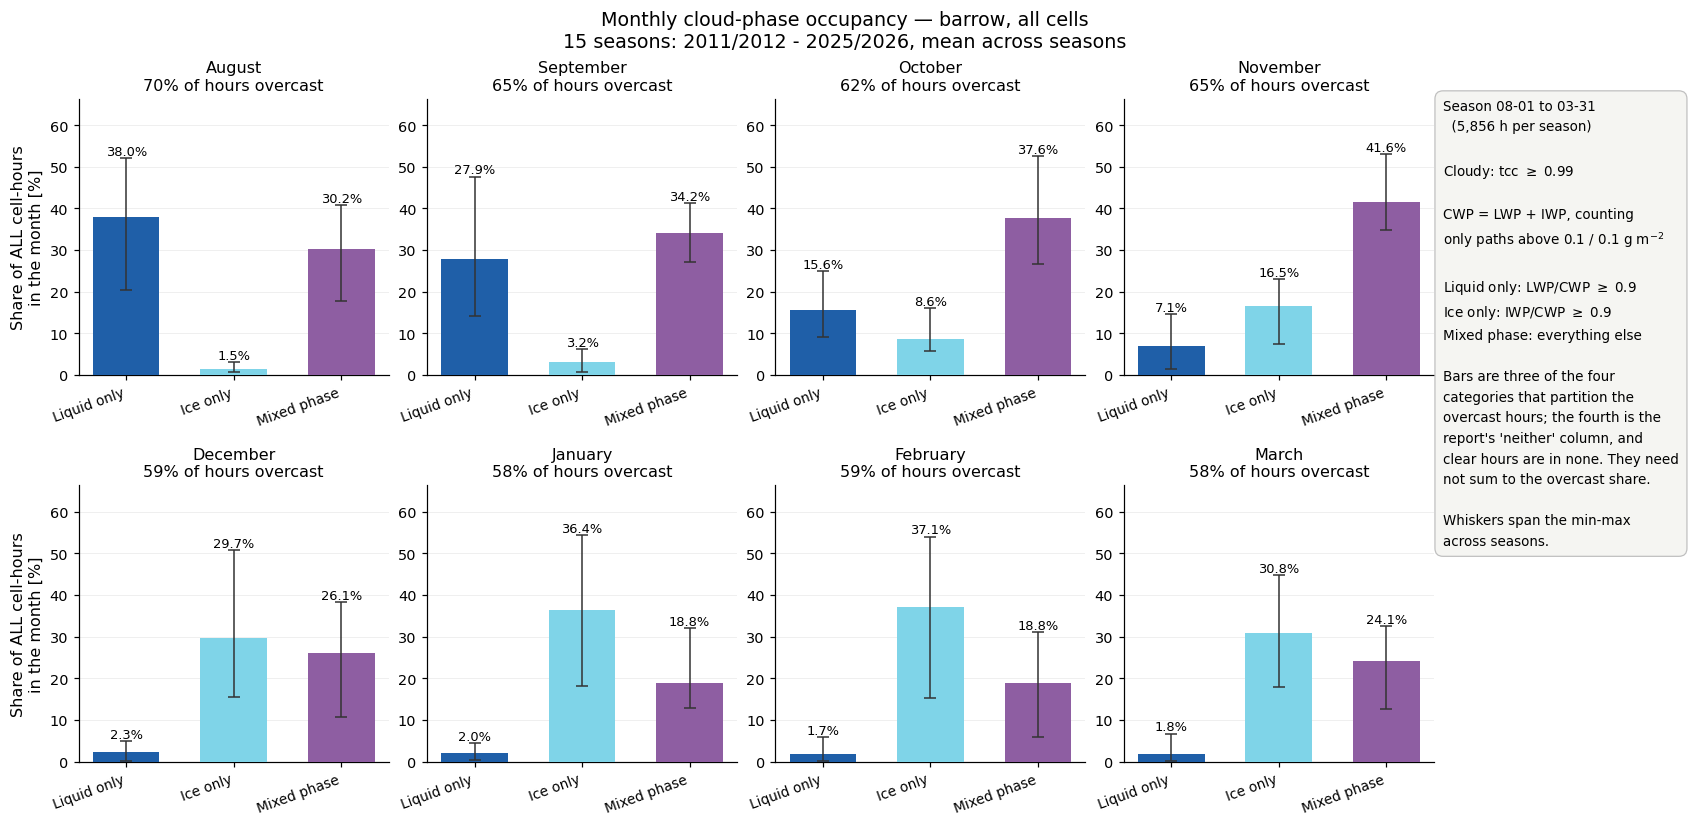

In [30]:
lwph.fig_monthly_phase_fraction(A, out_dir=SAVE_DIR);

#### The same, restricted to one surface class

  -> figures/fraction_limits/barrow_monthly_phase_fraction_open_ocean_mean2011-2025.png
  -> figures/fraction_limits/barrow_monthly_phase_fraction_sea_ice_mean2011-2025.png
  -> figures/fraction_limits/barrow_monthly_phase_fraction_arm_site_mean2011-2025.png


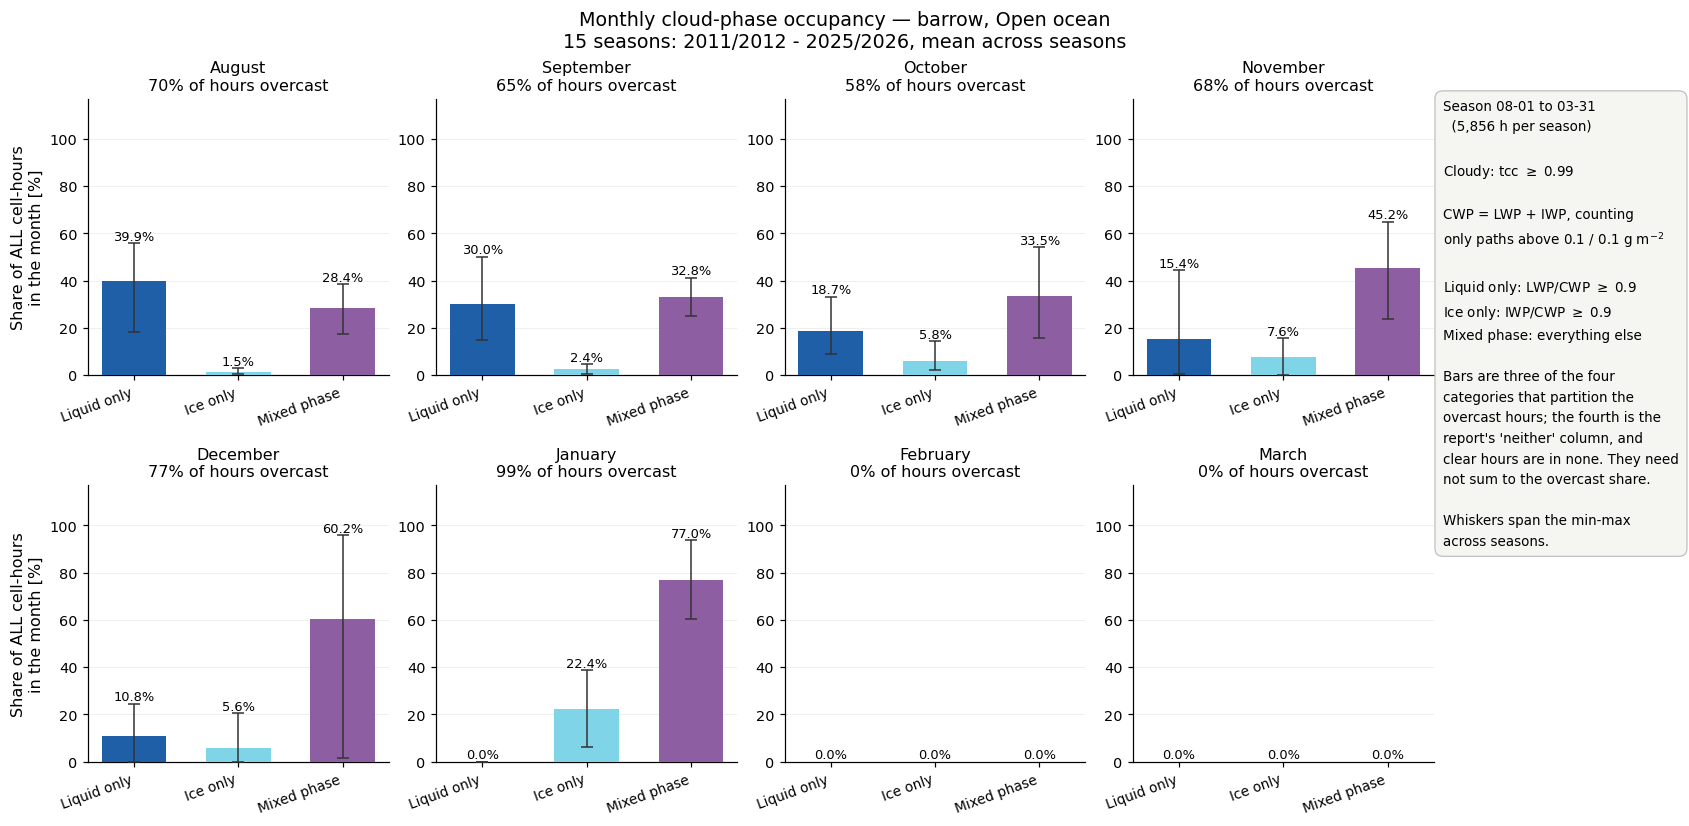

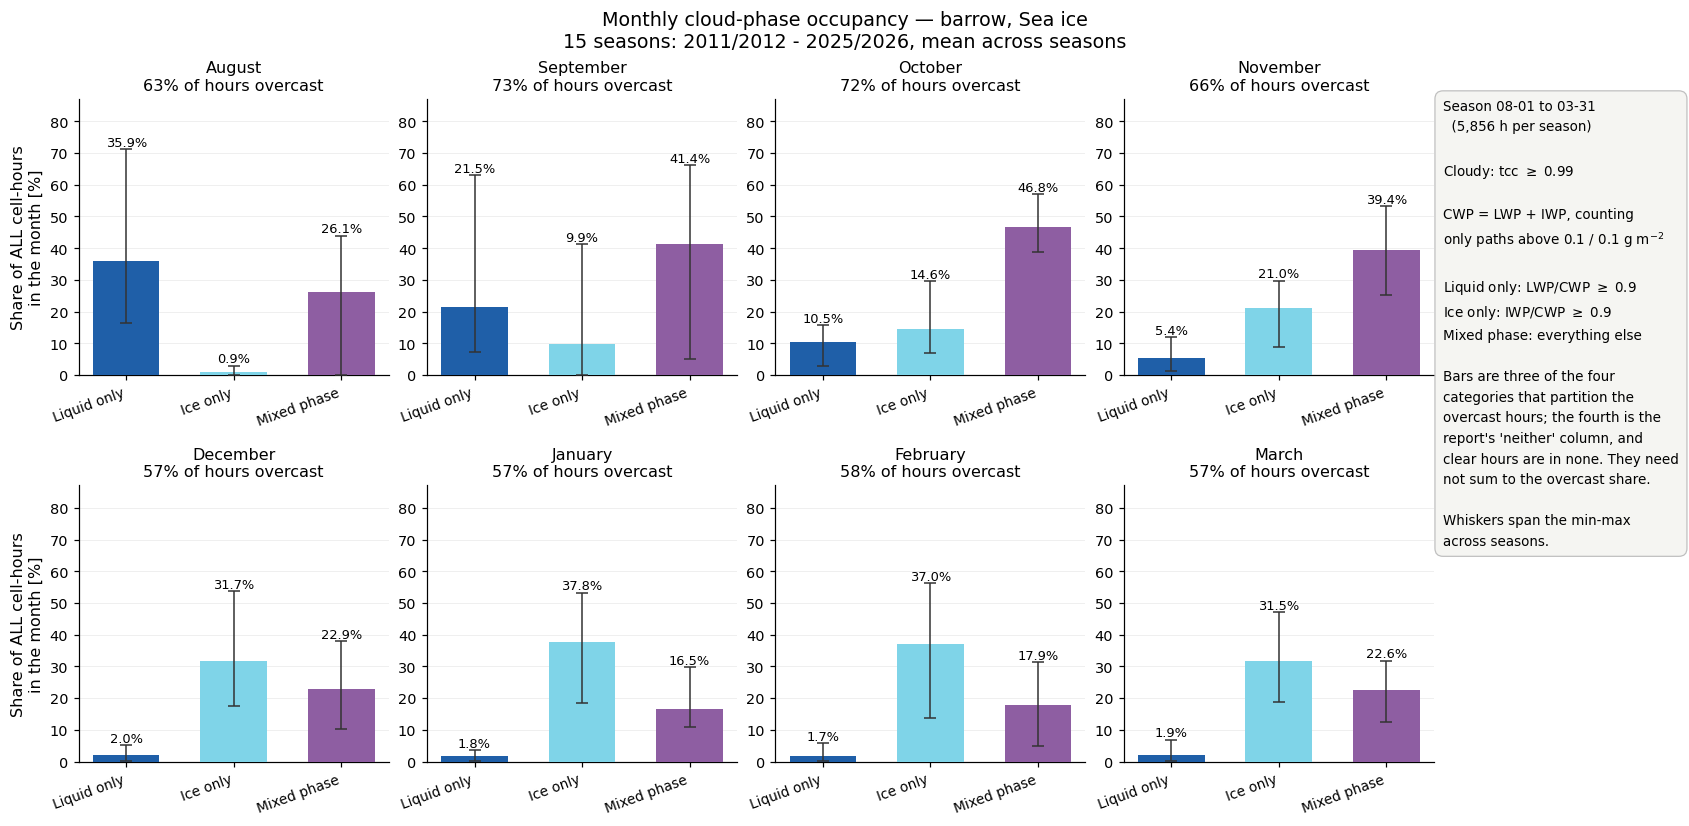

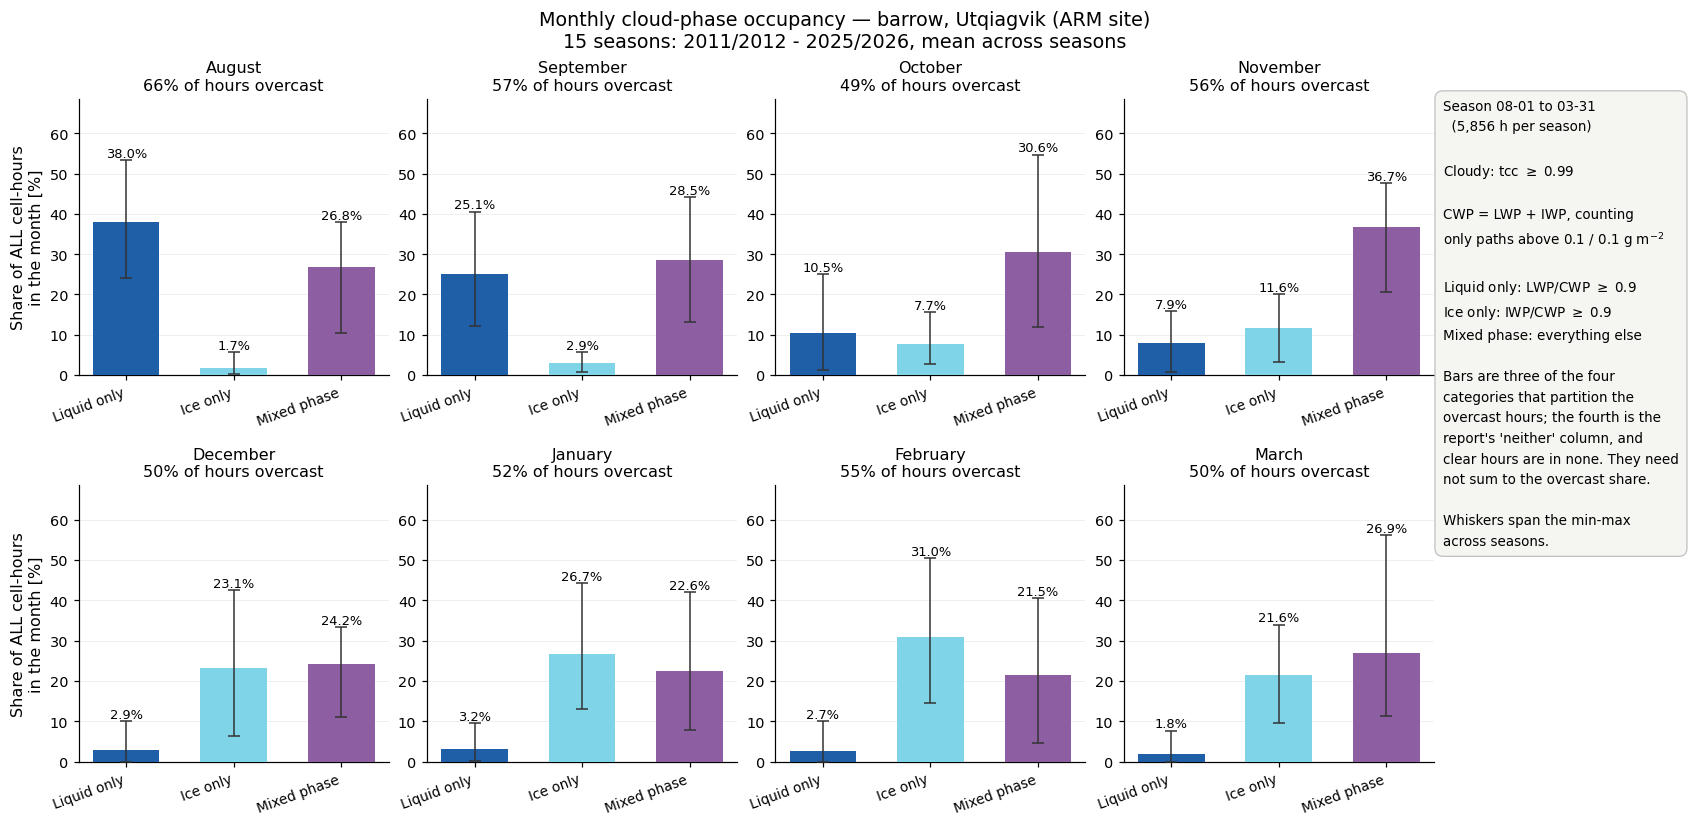

In [31]:
for sc in ("open_ocean", "sea_ice", "arm_site"):
    lwph.fig_monthly_phase_fraction(A, surface_class=sc, out_dir=SAVE_DIR)

## Redraw everything

  -> figures/fraction_limits/barrow_lwp_hist_surfaceclass_linear_mean2011-2025.png
  -> figures/fraction_limits/barrow_lwp_hist_surfaceclass_log_mean2011-2025.png
  -> figures/fraction_limits/barrow_monthly_phase_fraction_all_mean2011-2025.png


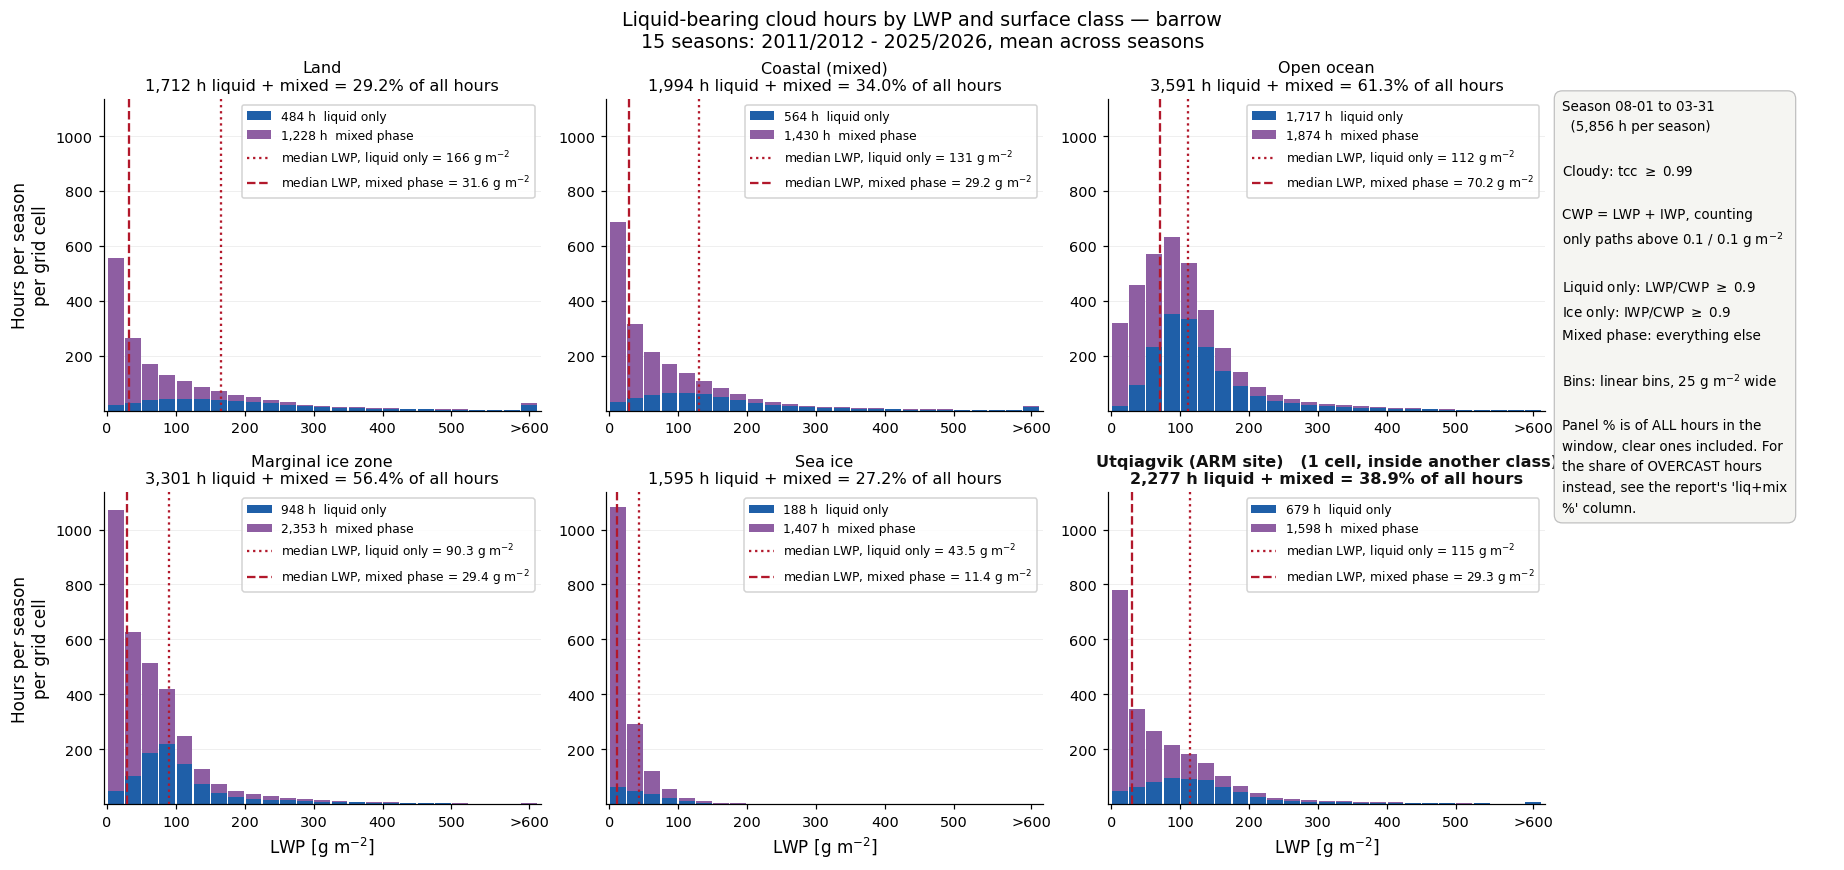

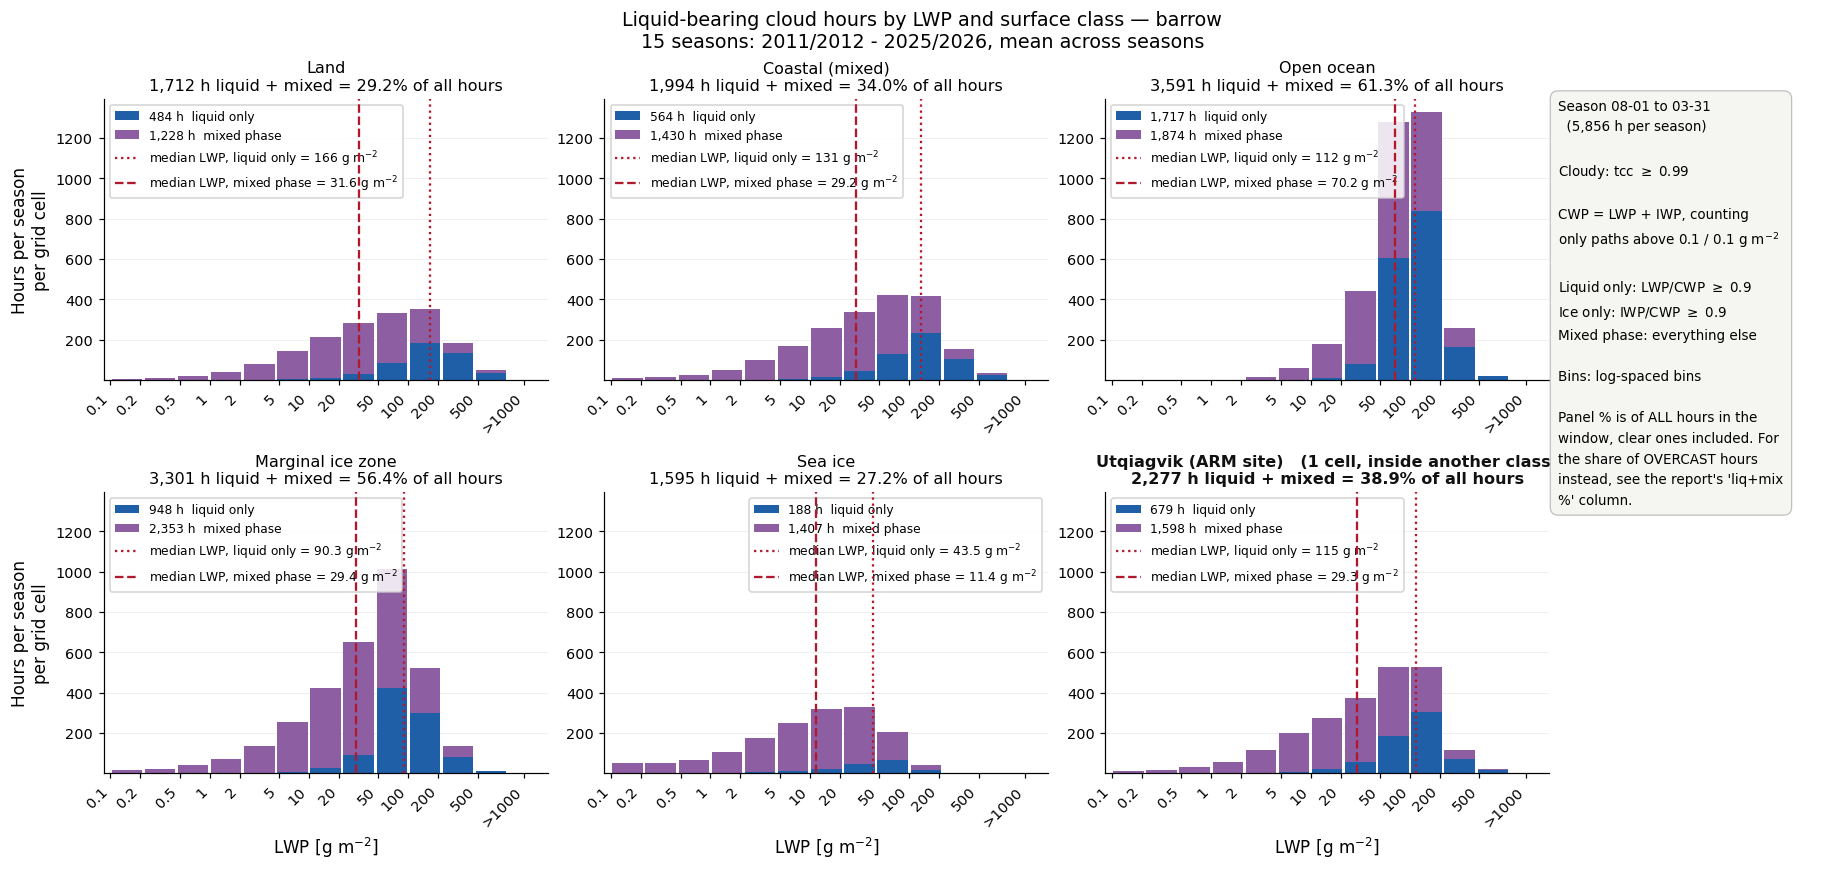

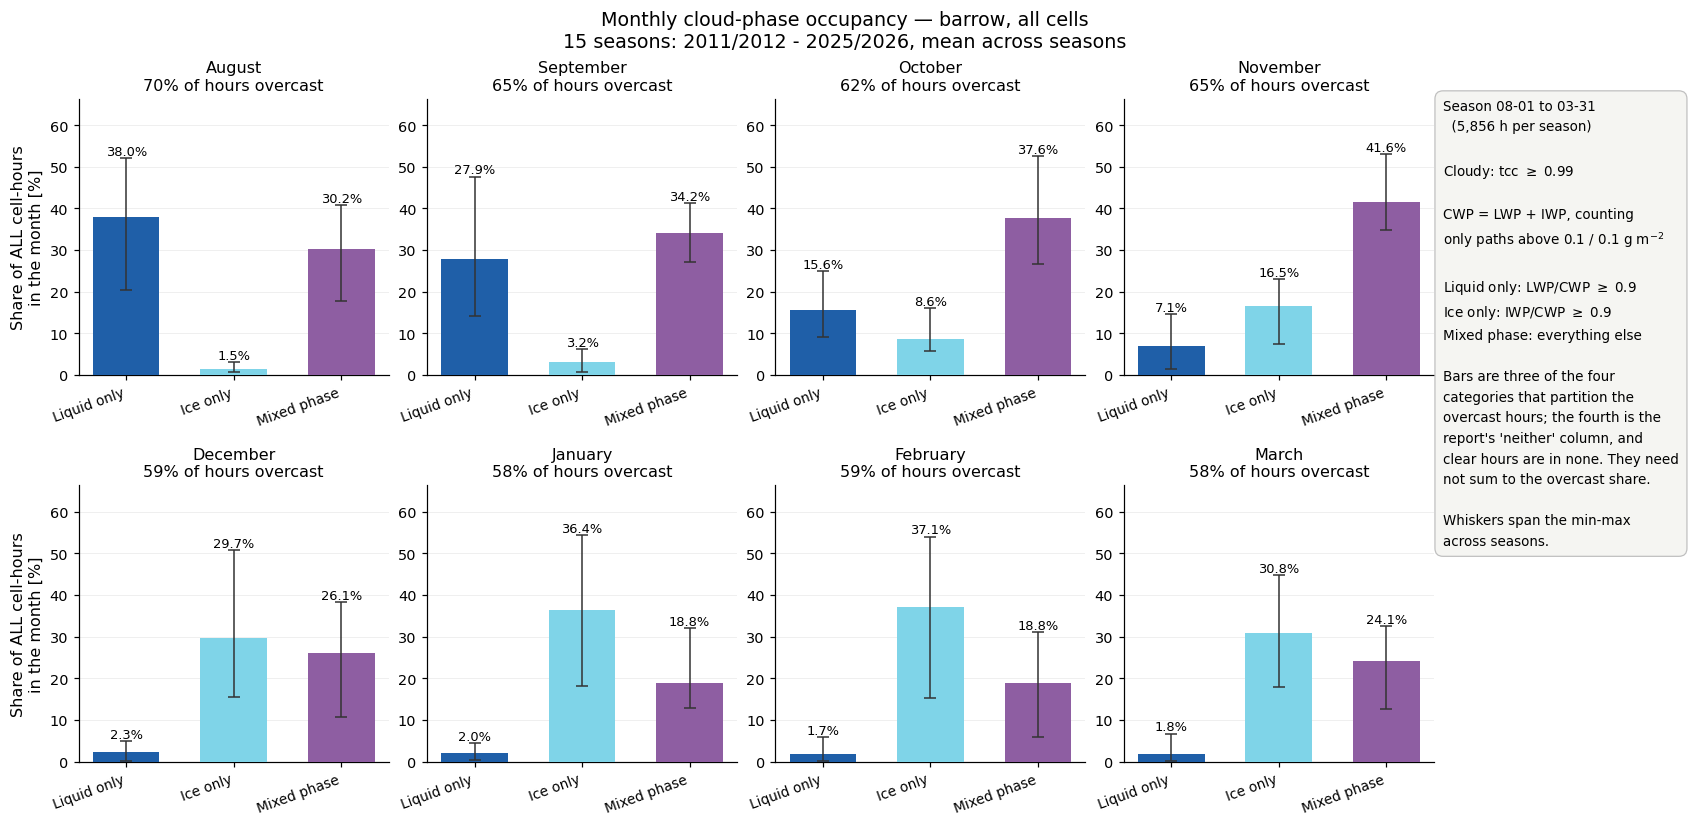

In [32]:
for fn in lwph.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR);

## Comparing the two schemes

Both notebooks use the same module, so an absolute-mode `Analysis` can be
built alongside this one and the two read against each other:

```python
A_abs = lwph.prepare(region="barrow", years=tuple(range(2015, 2026)),
                     phase_mode="absolute",
                     liquid_lwp_min=5.0, liquid_iwp_max=1.0,
                     mixed_lwp_min=1.0, mixed_iwp_min=1.0)
lwph.print_report(A_abs)
```

Expect the `liquid` column to be far larger here than there. A cloud with
LWP 50 and IWP 2 g m-2 is 96% liquid by share — liquid-only under this scheme —
but has more ice than `liquid_iwp_max = 1` allows, so absolute mode calls it
mixed. Neither is wrong; they are answering different questions.

### Varying the cuts

Any threshold change needs a fresh `prepare()`, since the phases are assigned
during the streaming pass:

```python
# stricter: a cloud must be 99% one species to be called pure
A_99 = lwph.prepare(region="barrow", years=(2019, 2020), phase_mode="fraction",
                    liquid_fraction_min=0.99, ice_fraction_min=0.99)

# looser: 60/60 still sums to 1.2 > 1, so it is legal, and 'mixed' shrinks
A_60 = lwph.prepare(region="barrow", years=(2019, 2020), phase_mode="fraction",
                    liquid_fraction_min=0.6, ice_fraction_min=0.6)

# 0.5 + 0.5 == 1 exactly -> refused, they would touch at f = 0.5
```

Drawing-only options can be changed on the existing `A` without reloading:

```python
A.args.y_scale = "log"
lwph.fig_linear(A)
```

### One caution about long-lived kernels

Building **several** `Analysis` objects while many figures are also open can
segfault the kernel. It is not this code: the crash is inside `netCDF4`/HDF5
acquiring a file handle while dask worker threads are live, and the HDF5 build
in this Anaconda environment is not thread-safe. Measured on a 42-file subset,
one `prepare()` plus nine figures plus three more `prepare()` calls in the same
process crashed 5 runs out of 5; the cell sequence in this notebook, run end to
end, passed 4 out of 4.

Practically: one or two `Analysis` objects per kernel is fine and is what the
cells above do. If you are sweeping many threshold combinations, restart the
kernel between batches, or run the sweep from the command line where each run
is its own process. Do **not** call `A.ds.close()` to free handles — that makes
the crash *more* likely, not less, because dask may still be reading through
them.